# Crawling Data kualitas udara di wilayah Dukun, Gresik

# Business Understanding

## Latar Belakang dan Tujuan Proyek

Tujuan utama dari proyek sains data ini adalah:

> **"Menganalisis kualitas udara di wilayah Gresik berdasarkan perubahan konsentrasi polutan CO,SO₂,NO₂ secara temporal selama periode 1 tahun terakhir menggunakan data satelit penginderaan jauh Sentinel-5P."**

Tujuan di atas dirumuskan secara spesifik agar mencakup komponen penting dalam proyek sains data:
- **Data:** Konsentrasi polutan (CO,SO₂,NO₂)
- **Periode waktu:** 1 tahun terakhir (31 Agustus 2025 hingga 31 Agustus 2026)
- **Wilayah:** Kecamatan Dukun, Gresik (berdasarkan batas koordinat wilayah)
- **Analisis:** Analisis temporal (*Time Series*)
- **Output:** Visualisasi data dan penarikan kesimpulan terkait tren kualitas udara

# Data Understanding

Berdasarkan ketersediaan instrumen (*band*) pada satelit **Sentinel-5P** yang digunakan dalam proyek ini, kita akan berfokus pada NO₂

| Parameter | Nama Polutan | Mengapa Penting? | Sumber Umum |
| :---: | :--- | :--- | :--- |
| **NO₂** | *Nitrogen Dioxide* | Berkaitan erat dengan pembakaran kendaraan bermotor dan aktivitas kawasan industri. | Asap kendaraan bermotor, pabrik industri, dan pembangkit listrik. |
| **CO** | *Carbon Monoxide* | Merupakan indikator terjadinya proses pembakaran yang tidak sempurna. | Kendaraan bermotor dan pembakaran bahan bakar. |
| **SO₂** | *Sulfur Dioxide* | Sangat relevan untuk melacak emisi dari aktivitas pembakaran bahan bakar fosil yang mengandung sulfur (belerang). | Kawasan industri, pembangkit listrik, dan pembakaran batu bara/minyak. |

## Eksplorasi data - Analisis kualitas udara wilayah Gresik

### Sumber Data (Data Source)
Data kualitas udara yang digunakan bersumber dari pantauan satelit penginderaan jauh **Sentinel-5P (S5P) Precursor**. Satelit ini dilengkapi instrumen TROPOMI yang sangat sensitif dalam mendeteksi komposisi gas di atmosfer. Pengambilan data dilakukan secara komputasional (*crawling*) menggunakan platform Copernicus Data Space melalui pustaka/API `openeo`.

### Spesifikasi Pengambilan Data (Data Scope)
* **Cakupan Spasial (*Spatial Extent*):** Pengambilan data difokuskan secara eksklusif pada *Area of Interest* (AOI) Kecamatan Dukun, Gresik. Ekstraksi menggunakan *Bounding Box* koordinat yang mencakup wilayah daratan dan pesisir sekitar Gresik.
* **Cakupan Temporal (*Temporal Extent*):** Data historis ditarik mulai dari **31 Agustus 2025 hingga 31 Agustus 2026** guna menangkap variasi harian, bulanan, maupun musiman selama lebih dari 1 tahun terakhir.
* **Agregasi (*Aggregation*):**
  * *Temporal*: Data harian diagregasi dengan menghitung nilai rata-rata (*daily mean*) untuk menghindari duplikasi observasi pada hari yang sama.
  * *Spasial*: Seluruh nilai piksel satelit yang jatuh di dalam batas koordinat Dukun, Gresik dirata-ratakan (*spatial mean*), menghasilkan satu nilai representatif untuk keseluruhan area pada hari tersebut.

### Deskripsi Variabel (Features Description)
Terdapat variabel polutan utama (NO₂) dan satu variabel waktu yang diekstrak:
1. **NO₂ (Nitrogen Dioksida):** Indikator pembakaran bahan bakar, relevan untuk memantau emisi lalu lintas dan kawasan industri di Gresik.
2. **Date (Tanggal):** Indeks waktu perekaman satelit dalam format YYYY-MM-DD.

### Pertimbangan Kualitas Data
Dalam memproses data satelit ini, beberapa hal perlu diperhatikan:
* **Missing Values (Kekosongan Data):** Tutupan awan yang tebal dapat menghalangi sensor satelit merekam permukaan bumi secara sempurna, menghasilkan baris data kosong (NaN).
* **Outliers (Pencilan):** Nilai polutan yang melompat drastis pada hari tertentu harus dicek apakah itu anomali sensor, atau benar-benar ada fenomena nyata (misal: kebakaran atau lonjakan aktivitas pabrik).


### Crawling Data

In [1]:
# Install library untuk crawling dan manipulasi data
!pip install openeo netCDF4 pandas numpy

In [2]:
# Koneksi ke Server Copernicus (OpenEO)
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


#### Eksekusi Crawling Data Satelit

In [6]:
# Polygon Wilayah Kecamatan Dukun
dukun_aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.4176093, -6.9520018],
            [112.4965324, -6.9660151],
            [112.5251805, -6.9804942],
            [112.525, -7.0],
            [112.51, -7.02],
            [112.48, -7.025],
            [112.44, -7.015],
            [112.3681227, -6.9870542],
            [112.381574, -6.9581535],
            [112.4176093, -6.9520018]
        ]
    ]
}

# Bounding Box Kecamatan Dukun (Diambil dari nilai min/max koordinat di atas)
bbox_dukun = {
    "west": 112.3681227,    # Bujur terkecil (Paling Barat)
    "south": -7.025,        # Lintang terkecil (Paling Selatan)
    "east": 112.5251805,    # Bujur terbesar (Paling Timur)
    "north": -6.9520018     # Lintang terbesar (Paling Utara)
}

rentang_waktu = ["2025-08-31", "2026-08-31"]

# Fungsi bantuan untuk memudahkan load dan agregasi
def crawl_polutan(band_name):
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=rentang_waktu,
        spatial_extent=bbox_dukun,
        bands=[band_name]
    )
    
    # Agregasi waktu (rata-rata harian)
    daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    
    # Agregasi spasial (rata-rata di dalam poligon GeoJSON Dukun)
    aoi_mean = daily.aggregate_spatial(reducer="mean", geometries=dukun_aoi) # Diubah menggunakan dukun_aoi
    
    return aoi_mean

# Menyiapkan proses (data cube) untuk masing-masing polutan di Dukun
s5p_NO2 = crawl_polutan("NO2")
s5p_SO2 = crawl_polutan("SO2")
s5p_CO = crawl_polutan("CO")

In [ ]:
# Eksekusi job dan simpan ke file NetCDF (.nc)
print("Memulai NO2...")
s5p_NO2.execute_batch(title="NO2_Dukun", outputfile="NO2_Dukun.nc")
print("Memulai CO...")
s5p_CO.execute_batch(title="CO_Gresik", outputfile="CO_Dukun.nc")
print("Memulai SO2...")
s5p_SO2.execute_batch(title="SO2_Gresik", outputfile="SO2_Dukun.nc")

print("file selesai!")

Memulai NO2...
0:00:00 Job 'j-26091812003542d8924f27d7f758defd': send 'start'
0:00:04 Job 'j-26091812003542d8924f27d7f758defd': queued (progress 0%)
0:00:09 Job 'j-26091812003542d8924f27d7f758defd': queued (progress 0%)
0:00:16 Job 'j-26091812003542d8924f27d7f758defd': queued (progress 0%)
0:00:24 Job 'j-26091812003542d8924f27d7f758defd': queued (progress 0%)
0:00:34 Job 'j-26091812003542d8924f27d7f758defd': queued (progress 0%)
0:00:46 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:01:02 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:01:21 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:01:46 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:02:16 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:02:53 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:03:40 Job 'j-26091812003542d8924f27d7f758defd': running (progress N/A)
0:04:39 Job 'j-26091812003542d8924f27d7f758defd': finish

#### Transformasi Data Mentah (NetCDF ke CSV)

File keluaran Copernicus berformat `.nc` bersifat multidimensi. Kita perlu mengekstrak array konsentrasi polutan dan waktunya, lalu mengonversinya menjadi DataFrame dua dimensi (`.csv`) agar siap pakai untuk analisis lanjutan.

In [8]:
import netCDF4
import pandas as pd
import functools

# Daftar polutan dan nama file .nc yang sudah diunduh
polutan_list = ["NO2", "CO", "SO2"]
file_nc = ["NO2_Dukun.nc", "CO_Dukun.nc", "SO2_Dukun.nc"]

# List untuk menyimpan DataFrame masing-masing polutan sementara
dfs_list = []

for polutan, file in zip(polutan_list, file_nc):
    try:
        ds = netCDF4.Dataset(file)
        kadar = ds.variables[polutan][:].squeeze() 
        
        # Ekstrak tanggal SPESIFIK untuk file ini
        time_var = ds.variables["t"]
        try:
            dates = netCDF4.num2date(time_var[:], units=time_var.units)
        except Exception:
            dates = time_var[:]
        new_dates = [d.strftime('%Y-%m-%d') for d in dates]
            
        df_temp = pd.DataFrame({
            "date": pd.to_datetime(new_dates),
            polutan: kadar
        })
        
        dfs_list.append(df_temp)
        print(f"Berhasil mengekstrak {polutan}")
        
    except Exception as e:
        print(f"Error memproses file {file}: {e}")

# Proses Penggabungan (Merge) berdasarkan kolom 'date'
if dfs_list:
    df_gabungan = functools.reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs_list)
    df_gabungan = df_gabungan.sort_values('date').reset_index(drop=True)    
    df_gabungan['date'] = df_gabungan['date'].dt.strftime('%Y-%m-%d')
            
    # Export langsung menjadi 1 file CSV tunggal
    nama_file_akhir = "3Polutan_Dukun_Terkini.csv"
    df_gabungan.to_csv(nama_file_akhir, index=False)
    print(f"\n SUKSES: Semua data berhasil digabung menjadi 1 file -> {nama_file_akhir}")
    
else:
    print("Gagal mengekstrak data dari file NetCDF.")

Berhasil mengekstrak NO2
Berhasil mengekstrak CO
Berhasil mengekstrak SO2

 SUKSES: Semua data berhasil digabung menjadi 1 file -> 3Polutan_Dukun_Terkini.csv


#### Visualisasi Hasil dengan Grafik Kartesius
Menampilkan grafik kartesius (*line plot*) deret waktu konsentrasi polutan kualitas udara (NO₂, CO, SO₂, O₃) di area Kabupaten Gresik selama rentang waktu lebih dari 1 tahun terakhir.

In [9]:
!pip install matplotlib

#### Visualisasi NO2

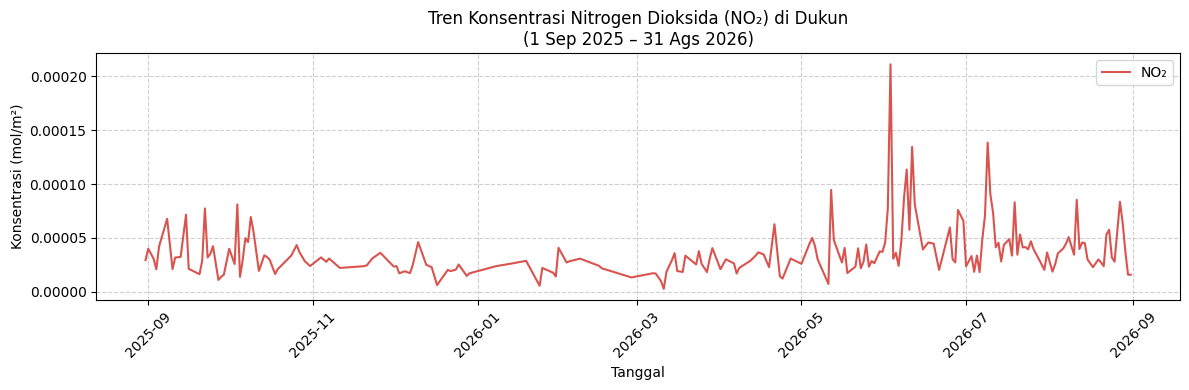

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("3Polutan_Dukun_Terkini.csv")

df_no2 = df_final.dropna(subset=['NO2']).copy()
df_no2['date'] = pd.to_datetime(df_no2['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_no2['date'], df_no2['NO2'], linewidth=1.5, label="NO₂", color="#d9534f")

ax.set_title("Tren Konsentrasi Nitrogen Dioksida (NO₂) di Dukun\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Visualisasi SO2

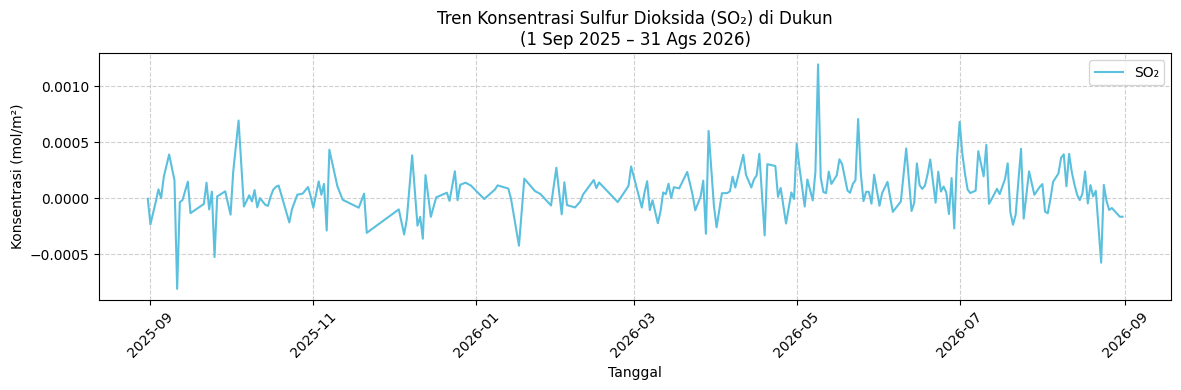

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("3Polutan_Dukun_Terkini.csv")

df_so2 = df_final.dropna(subset=['SO2']).copy()
df_so2['date'] = pd.to_datetime(df_so2['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_so2['date'], df_so2['SO2'], linewidth=1.5, label="SO₂", color="#5bc0de")

ax.set_title("Tren Konsentrasi Sulfur Dioksida (SO₂) di Dukun\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Visualisasi CO

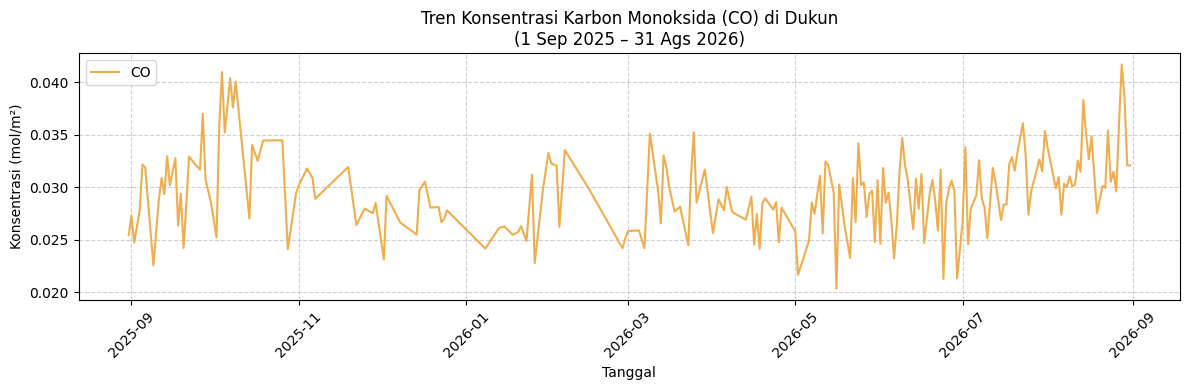

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("3Polutan_Dukun_Terkini.csv")

df_co = df_final.dropna(subset=['CO']).copy()
df_co['date'] = pd.to_datetime(df_co['date'])

fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.plot(df_co['date'], df_co['CO'], linewidth=1.5, label="CO", color="#f0ad4e")

ax.set_title("Tren Konsentrasi Karbon Monoksida (CO) di Dukun\n(1 Sep 2025 – 31 Ags 2026)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi (mol/m²)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Deteksi Missing Values

Sebelum mengisi data, kita harus tahu seberapa banyak data yang hilang. Kekosongan bisa berupa baris kosong (NaN) atau tanggal yang terlewat (Missing Dates) akibat satelit tidak merekam pada hari tersebut.

In [35]:
import pandas as pd

# 1. Load Data
df = pd.read_csv("3Polutan_Dukun_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])

# 2. Cek Missing Value Polutan
polutan = ['NO2', 'SO2', 'CO']

hasil = []

for kolom in polutan:
    jumlah_missing = df[kolom].isna().sum()
    total_data = len(df)
    persentase = jumlah_missing / total_data * 100

    hasil.append({
        'Polutan': kolom,
        'Total Data': total_data,
        'Missing Value': jumlah_missing,
        'Persentase Missing (%)': round(persentase, 2)
    })

hasil_df = pd.DataFrame(hasil)

print("\n=== MISSING VALUE POLUTAN ===")
print(hasil_df.to_string(index=False))


=== MISSING VALUE POLUTAN ===
Polutan  Total Data  Missing Value  Persentase Missing (%)
    NO2         366             52                   14.21
    SO2         366             54                   14.75
     CO         366             47                   12.84


### Deteksi Outliers

Sesuai dengan referensi analisis Anda sebelumnya, kita menggunakan algoritma IsolationForest dari Scikit-Learn untuk mendeteksi lonjakan nilai NO2 yang tidak wajar.

In [37]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("3Polutan_Dukun_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
kolom_polutan = ['NO2', 'CO', 'SO2']
for kolom in kolom_polutan:
    df_clean = df.dropna(subset=[kolom]).copy()
    model = IsolationForest(
        contamination=0.05,
        random_state=42
    )
    df_clean['outlier'] = model.fit_predict(df_clean[[kolom]])
    jumlah_outlier = (df_clean['outlier'] == -1).sum()
    print(f"{kolom}: {jumlah_outlier} outlier terdeteksi")
    df = df.merge(
        df_clean[['date', 'outlier']],
        on='date',
        how='left'
    )
    df.rename(
        columns={'outlier': f'outlier_{kolom}'},
        inplace=True
    )

NO2: 16 outlier terdeteksi
CO: 16 outlier terdeteksi
SO2: 16 outlier terdeteksi


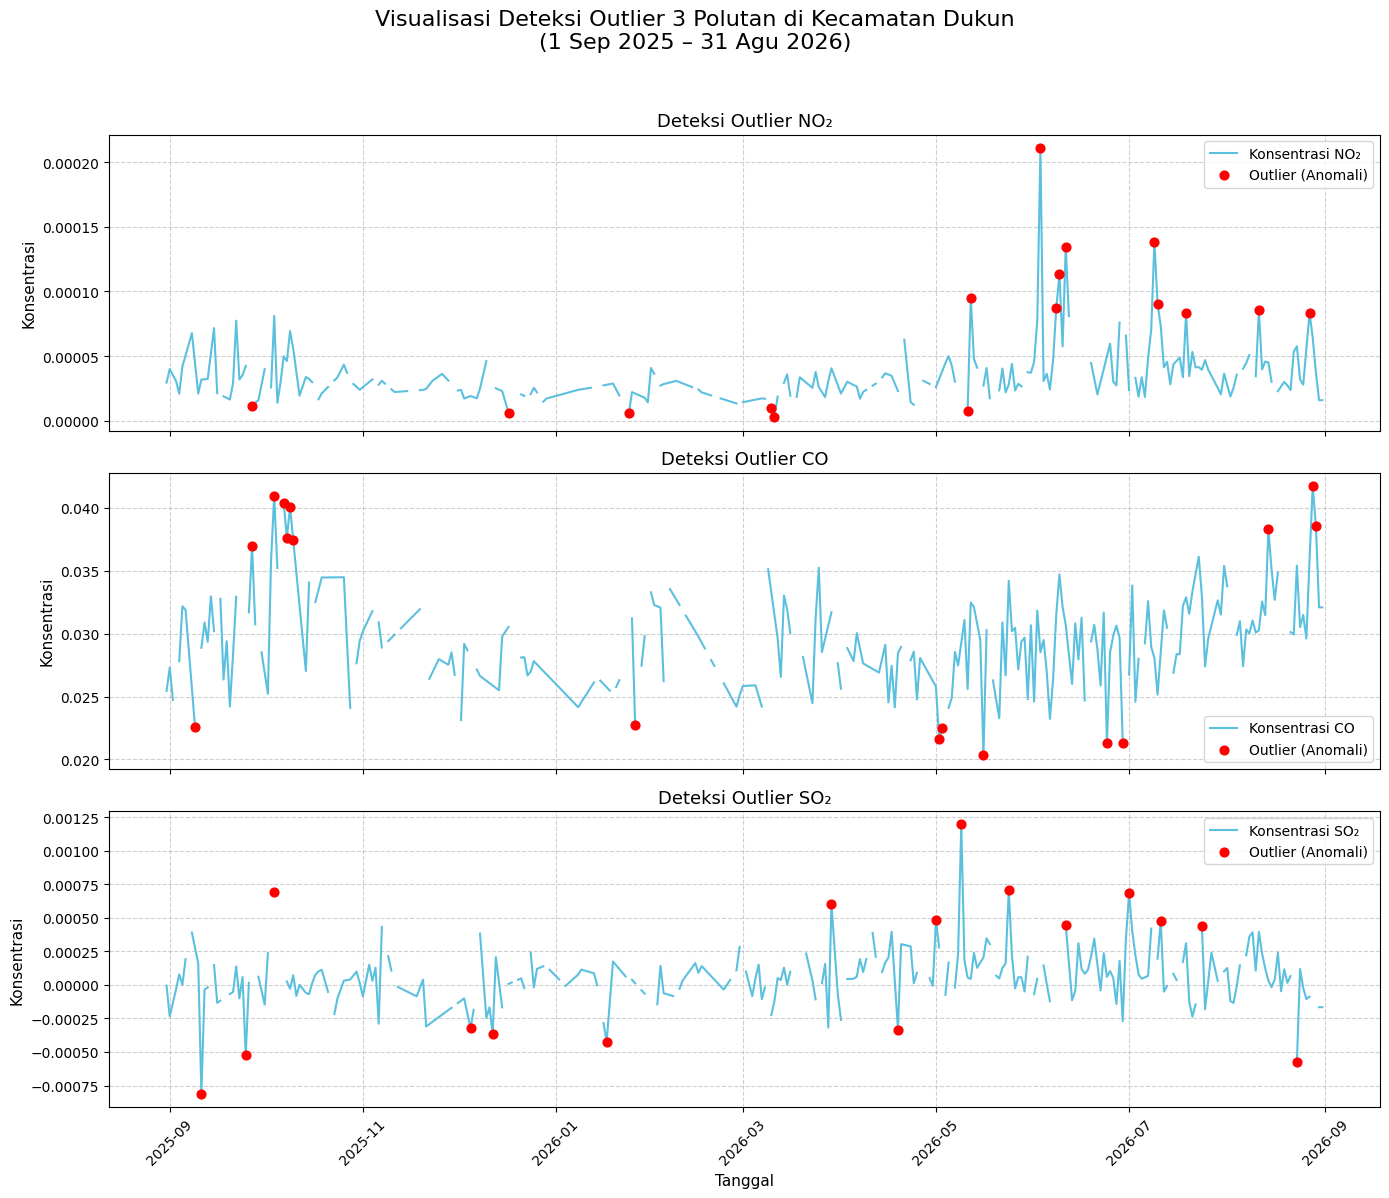

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

df['date'] = pd.to_datetime(df['date'])

kolom_polutan = ['NO2', 'CO', 'SO2']
nama_polutan = ['NO₂', 'CO', 'SO₂']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), dpi=100, sharex=True)

for ax, kolom, nama in zip(axes, kolom_polutan, nama_polutan):
    ax.plot(
        df['date'],
        df[kolom],
        label=f'Konsentrasi {nama}',
        color='#5bc0de',
        linewidth=1.5
    )

    outliers = df[df[f'outlier_{kolom}'] == -1]

    ax.scatter(
        outliers['date'],
        outliers[kolom],
        color='red',
        label='Outlier (Anomali)',
        s=40,
        zorder=2
    )

    ax.set_title(f'Deteksi Outlier {nama}', fontsize=13)
    ax.set_ylabel('Konsentrasi', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

axes[-1].set_xlabel('Tanggal', fontsize=11)

fig.suptitle(
    'Visualisasi Deteksi Outlier 3 Polutan di Kecamatan Dukun\n'
    '(1 Sep 2025 – 31 Agu 2026)',
    fontsize=16,
    y=0.995
)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Imputasi Missing Values.

Tahap ini akan memasukkan tanggal-tanggal yang bolong ke dalam tabel, lalu mengisi nilai NO2 yang kosong menggunakan Interpolasi Waktu (Time Interpolation).

In [42]:
import pandas as pd
import numpy as np

df = pd.read_csv("3Polutan_Dukun_Terkini.csv")

df['date'] = pd.to_datetime(df['date'])

kolom_polutan = ['NO2', 'CO', 'SO2']

start_date = "2025-09-01"
end_date = "2026-08-31"

full_range = pd.date_range(
    start=start_date,
    end=end_date,
    freq='D'
)

df = df.set_index('date')
df = df.reindex(full_range)

print("Jumlah missing sebelum imputasi:")

for kolom in kolom_polutan:
    print(f"{kolom}: {df[kolom].isna().sum()}")

for kolom in kolom_polutan:
    df[f'{kolom}_imputed'] = df[kolom].interpolate(
        method='time'
    )

df = df.reset_index().rename(
    columns={'index': 'date'}
)

print("\nSisa missing setelah imputasi:")

for kolom in kolom_polutan:
    print(f"{kolom}: {df[f'{kolom}_imputed'].isna().sum()}")

nama_file_bersih = "3Polutan_Dukun_Cleaned.csv"

df.to_csv(
    nama_file_bersih,
    index=False
)

print(f"\nSUKSES! Data bersih disimpan ke: {nama_file_bersih}")
print(f"Total data: {len(df)} hari")

Jumlah missing sebelum imputasi:
NO2: 52
CO: 47
SO2: 54

Sisa missing setelah imputasi:
NO2: 0
CO: 0
SO2: 0

SUKSES! Data bersih disimpan ke: 3Polutan_Dukun_Cleaned.csv
Total data: 365 hari


### Visualisasi Hasil Imputasi

Setelah berhasil diisi, kita perlu membuktikan apakah hasil interpolasinya terlihat natural (tidak merusak bentuk grafik).

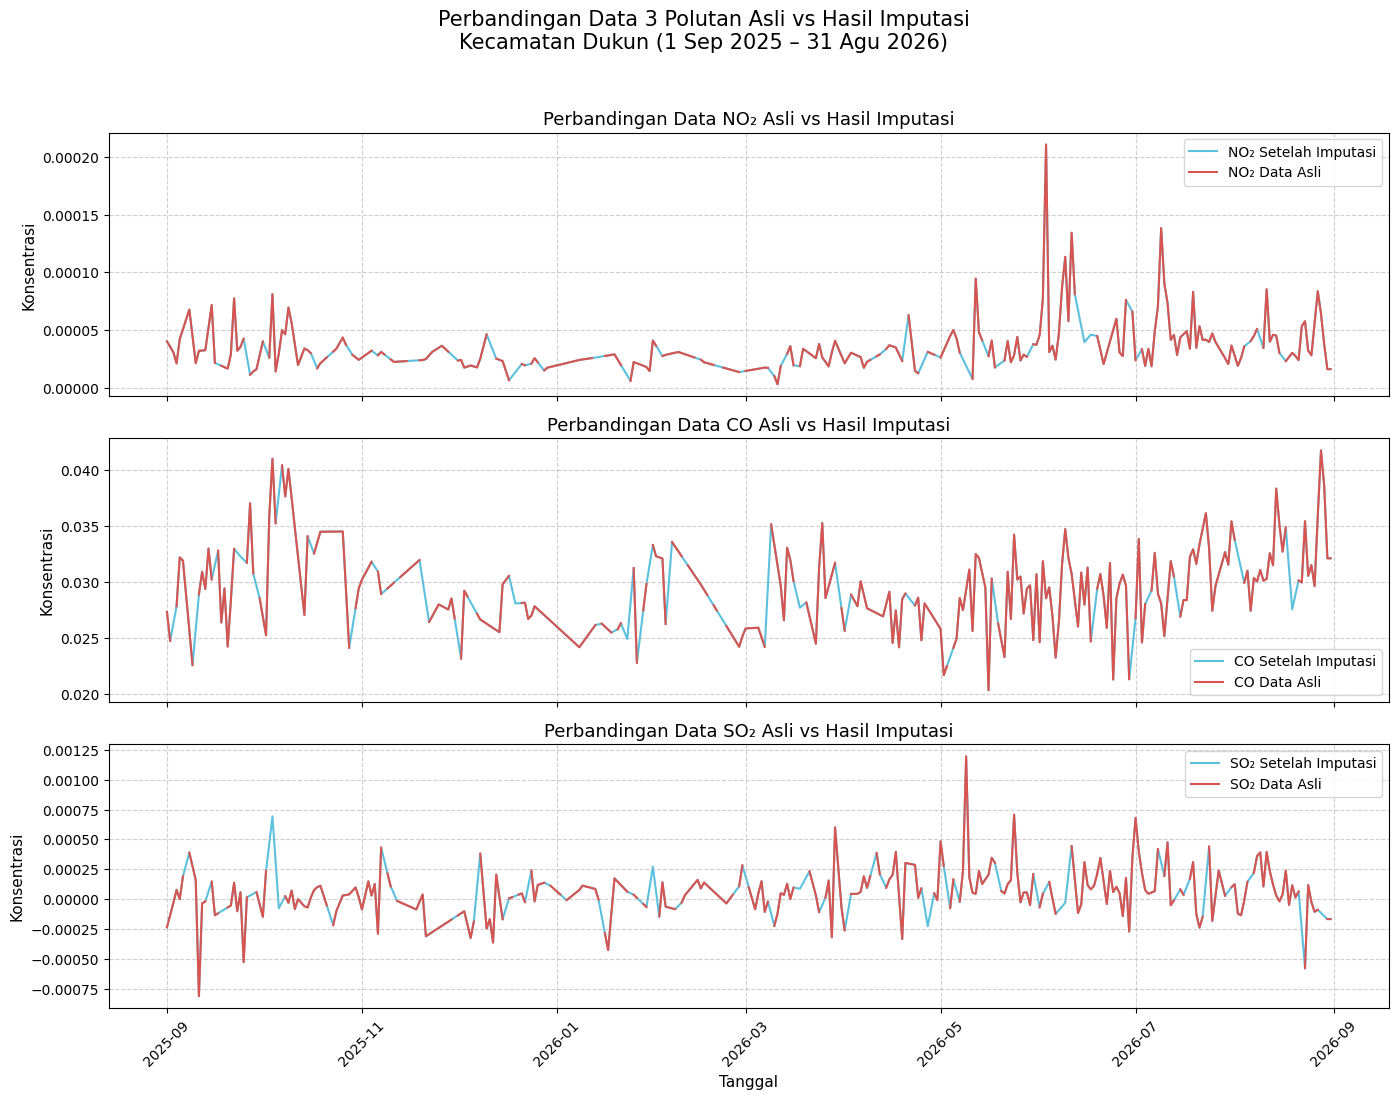

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 11), dpi=100, sharex=True)

polutan = [
    ('NO2', 'NO₂'),
    ('CO', 'CO'),
    ('SO2', 'SO₂')
]

for ax, (kolom, nama) in zip(axes, polutan):
    ax.plot(
        df['date'],
        df[f'{kolom}_imputed'],
        linewidth=1.5,
        label=f'{nama} Setelah Imputasi',
        color='#5bc0de',
        zorder=1
    )

    ax.plot(
        df['date'],
        df[kolom],
        linewidth=1.5,
        label=f'{nama} Data Asli',
        color='#d9534f',
        zorder=2
    )

    ax.set_title(f'Perbandingan Data {nama} Asli vs Hasil Imputasi', fontsize=13)
    ax.set_ylabel('Konsentrasi', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

axes[-1].set_xlabel('Tanggal', fontsize=11)

fig.suptitle(
    'Perbandingan Data 3 Polutan Asli vs Hasil Imputasi\n'
    'Kecamatan Dukun (1 Sep 2025 – 31 Agu 2026)',
    fontsize=15,
    y=0.995
)

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Penanganan Data

Data NO₂, CO, dan SO₂ diperiksa untuk menemukan missing value dan outlier.
Missing value diisi menggunakan interpolasi berbasis waktu.
Outlier ditangani dengan menggantinya menggunakan nilai hasil interpolasi.

In [45]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("3Polutan_Dukun_Cleaned.csv")

df['date'] = pd.to_datetime(df['date'])

kolom_polutan = ['NO2', 'CO', 'SO2']

for kolom in kolom_polutan:
    df[f'{kolom}_normalized'] = df[f'{kolom}_imputed']

    data_outlier = df.dropna(subset=[kolom])

    model = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    hasil = model.fit_predict(data_outlier[[kolom]])

    outlier_index = data_outlier.index[hasil == -1]

    df.loc[outlier_index, f'{kolom}_normalized'] = df.loc[
        outlier_index,
        f'{kolom}_imputed'
    ]

    print(f"{kolom}: {len(outlier_index)} outlier dinormalkan")

nama_file = "3Polutan_Dukun_Final.csv"

df.to_csv(
    nama_file,
    index=False
)

print(f"\nSUKSES! Data final disimpan sebagai: {nama_file}")

NO2: 16 outlier dinormalkan
CO: 16 outlier dinormalkan
SO2: 16 outlier dinormalkan

SUKSES! Data final disimpan sebagai: 3Polutan_Dukun_Final.csv
